# Tenacious-Bench — SimPO Judge Training (Colab T4)

**Week 11 · Day 5 · Path B (preference-tuned judge)**

Trains a Qwen 2.5 3B LoRA judge on the 965 preference pairs in [training_data/](training_data/) using SimPO (Meng et al., NeurIPS 2024).

**Pre-requisites (must be done before running this notebook):**

- Day 0 smoke test ([test.ipynb](test.ipynb)) passed end to end.
- HF write token in Colab Secrets as `HF_TOKEN`.
- Repo cloned with `training_data/train.jsonl` and `training_data/dev.jsonl` present.

**Expected wall time:** 30–90 min on T4. If not converging by 30 min, **kill it and check the data** — do not throw more compute (per challenge brief §Act IV).

**Cost:** $0 on Colab T4. RunPod 4090 ≈ $0.34/hr (cap $5).

**Expected folder layout in `/content/tenacious-bench/`:**

```
training/
  train_judge.py          ← training entrypoint
  colab_smoke_test.py     ← Day 0 smoke test
  requirements.txt        ← pinned deps (trl>=0.12.0)
  checkpoints/            ← created by this run (best by dev pairwise acc)
  training_run.log        ← loss + dev-acc every 100 steps
  training_summary.json   ← final hyperparams, wall time, cost
training_data/
  train.jsonl             ← 618 preference pairs
  dev.jsonl               ← 347 preference pairs
  build_cost_log.json     ← cost ledger (data-prep + training)
tenacious_bench_v0.1/
  train/  dev/  held_out/ ← source partitions (held_out is sealed)
```


## Step 1 — Check GPU


In [13]:
import subprocess, torch

print(
    subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout
    or "NO GPU — change runtime to T4"
)
print(f"torch={torch.__version__}  cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(
        f"GPU: {torch.cuda.get_device_name(0)}  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB"
    )
    print(f"bf16 supported: {torch.cuda.is_bf16_supported()}")

Fri May  1 07:56:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2 — Clone repo (skip if already cloned)


In [8]:
import os
REPO_URL = "https://github.com/sanoy24/tenacious-bench.git"  # ← edit me
if not os.path.isdir("/content/tenacious-bench-clone"):
    !git clone $REPO_URL /content/tenacious-bench-clone
%cd /content/tenacious-bench
!wc -l training_data/train.jsonl training_data/dev.jsonl

Cloning into '/content/tenacious-bench-clone'...
remote: Enumerating objects: 263, done.
remote: Counting objects: 100% (263/263), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 263 (delta 108), reused 232 (delta 79), pack-reused 0 (from 0)
Receiving objects: 100% (263/263), 706.16 KiB | 14.12 MiB/s, done.
Resolving deltas: 100% (108/108), done.
/content/tenacious-bench
wc: training_data/train.jsonl: No such file or directory
wc: training_data/dev.jsonl: No such file or directory
0 total


In [15]:
!git pull

Updating 400b1c9..f33098c
Fast-forward
 training/train_judge.py | 5 +++++
 1 file changed, 5 insertions(+)


## Step 3 — Install dependencies


In [14]:
!pip install -q unsloth
!pip install -q "trl>=0.12.0" "peft>=0.12.0" "datasets>=2.20.0" "accelerate>=0.33.0" \
               sentencepiece protobuf "huggingface_hub>=0.24.0"
import trl, peft, transformers
print(f"trl={trl.__version__}  peft={peft.__version__}  transformers={transformers.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 13.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 130.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 106.7 MB/s eta 0:00:00
   

trl=0.24.0  peft=0.19.1  transformers=5.5.0


## Step 4 — HuggingFace authentication

Add a write-scope token at Colab sidebar → 🔑 → `HF_TOKEN`.


In [4]:
from huggingface_hub import login

login()

## Step 5 — Core training run (γ=1.0, γ/β=0.5)

This is the **headline run**. SimPO with γ=1.0, β=2.0 → γ/β=0.5, the best-region from the SimPO paper's Table 3 (Mistral-Base / Llama-3-8B-Instruct). Runs `training/train_judge.py` which:

- Loads `unsloth/Qwen2.5-3B-Instruct` in 16-bit + LoRA (rank=16, α=32).
- Trains on `training_data/train.jsonl` (618 pairs).
- Evaluates dev pairwise accuracy every 100 steps; keeps the best checkpoint.
- Logs to `training/training_run.log`.
- Pushes the LoRA adapter to HuggingFace (private).
- Appends a cost record to `training_data/build_cost_log.json`.

**Replace `<your-hf-user>`.** Drop `--hf-repo` for a local-only run.


In [17]:
HF_USER = "sanoy24"  # ← edit me
!python training/train_judge.py \
    --gamma 1.0 \
    --platform colab \
    --hf-repo $HF_USER/tenacious-judge-qwen25-3b

2026-05-01 02:06:44,252 INFO ============================================================
2026-05-01 02:06:44,252 INFO Tenacious-Bench SimPO Judge Training
2026-05-01 02:06:44,252 INFO model=unsloth/Qwen2.5-3B-Instruct  β=2.0  γ=1.0  γ/β=0.500
2026-05-01 02:06:44,252 INFO LoRA rank=16  alpha=32  seed=42
2026-05-01 02:06:44,252 INFO platform=colab  hourly_rate=$0.00/hr
2026-05-01 02:06:44,252 INFO train=/content/tenacious-bench/training_data/train.jsonl  dev=/content/tenacious-bench/training_data/dev.jsonl
2026-05-01 02:06:44,252 INFO ============================================================
2026-05-01 02:06:44,280 INFO Loaded 618 train pairs, 347 dev pairs
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
2026-05-01 02:07:00,499 INFO Unsloth found — loading in 16-bit fp16
2026-05-01 02:07:00,670 INFO HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
2026-05-01 02:07:00,819 

## Step 6 — Ablation run (γ=1.5, γ/β=0.75)

Per `methodology_rationale.md`: γ=1.5 (γ/β=0.75) is the upper-edge SimPO ablation variant. Both γ values are reported in `ablations/ablation_results.json` on Day 6.

Skip if Step 5 ate your Colab session quota — re-attach a fresh runtime and run this alone.


In [18]:
!python training/train_judge.py \
    --gamma 1.5 \
    --platform colab \
    --hf-repo $HF_USER/tenacious-judge-qwen25-3b-gamma15

2026-05-01 02:30:59,411 INFO ============================================================
2026-05-01 02:30:59,411 INFO Tenacious-Bench SimPO Judge Training
2026-05-01 02:30:59,411 INFO model=unsloth/Qwen2.5-3B-Instruct  β=2.0  γ=1.5  γ/β=0.750
2026-05-01 02:30:59,412 INFO LoRA rank=16  alpha=32  seed=42
2026-05-01 02:30:59,412 INFO platform=colab  hourly_rate=$0.00/hr
2026-05-01 02:30:59,412 INFO train=/content/tenacious-bench/training_data/train.jsonl  dev=/content/tenacious-bench/training_data/dev.jsonl
2026-05-01 02:30:59,412 INFO ============================================================
2026-05-01 02:30:59,428 INFO Loaded 618 train pairs, 347 dev pairs
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
2026-05-01 02:31:16,180 INFO Unsloth found — loading in 16-bit fp16
2026-05-01 02:31:16,336 INFO HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
2026-05-01 02:31:16,551 

## Step 7 — Inspect loss curve & training summary


In [19]:
import json, pathlib

summary = json.loads(pathlib.Path("training/training_summary.json").read_text())
print(json.dumps(summary, indent=2))

{
  "model_id": "unsloth/Qwen2.5-3B-Instruct",
  "beta": 2.0,
  "gamma": 1.5,
  "gamma_beta_ratio": 0.75,
  "lora_rank": 16,
  "lora_alpha": 32,
  "seed": 42,
  "train_pairs": 618,
  "dev_pairs": 347,
  "num_epochs": 2,
  "effective_batch_size": 8,
  "learning_rate": 5e-05,
  "training_loss": 0.01618441540211699,
  "baseline_pairwise_acc": 0.98,
  "final_pairwise_acc": 1.0,
  "pairwise_acc_delta": 0.020000000000000018,
  "wall_time_min": 16.14,
  "platform": "colab",
  "hourly_rate_usd": 0.0,
  "cost_usd": 0.0
}


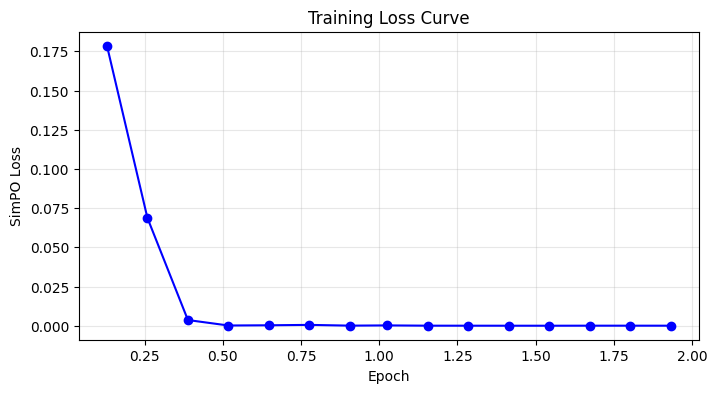

In [ ]:
import json
import matplotlib.pyplot as plt
import pathlib

# Read the official training state saved by the trainer
state_path = pathlib.Path(
    "/content/tenacious-bench/training/checkpoints/checkpoint-156/trainer_state.json"
)

if not state_path.exists():
    print(f"Error: Could not find {state_path}")
else:
    state = json.loads(state_path.read_text())

    epochs = []
    losses = []

    # Extract the training loss history
    for record in state.get("log_history", []):
        if "loss" in record and "epoch" in record:
            epochs.append(record["epoch"])
            losses.append(record["loss"])

    if epochs:
        plt.figure(figsize=(8, 4))
        plt.plot(epochs, losses, marker="o", linestyle="-", color="b")
        plt.xlabel("Epoch")
        plt.ylabel("SimPO Loss")
        plt.title("Training Loss Curve")
        plt.grid(alpha=0.3)
        plt.show()
    else:
        print("Found the file, but no loss history was recorded in it.")

## Step 8 — Cost summary

Total spend across the week (data prep + training). Must stay under **$10** per the challenge brief's cost-discipline observable.


In [22]:
import json, pathlib
from collections import defaultdict

log = json.loads(pathlib.Path("training_data/build_cost_log.json").read_text())
totals = defaultdict(float)
for r in log:
    totals[r.get("bucket", "other")] += float(r.get("cost_usd", 0.0))
print(f"{'Bucket':<22} {'USD':>8}")
print("-" * 32)
for b, c in sorted(totals.items()):
    print(f"{b:<22} {c:>8.4f}")
print("-" * 32)
print(f"{'TOTAL':<22} {sum(totals.values()):>8.4f}  /  $10.00 budget")

Bucket                      USD
--------------------------------
training_compute         0.0000
--------------------------------
TOTAL                    0.0000  /  $10.00 budget


## Step 9 — Commit artifacts back to the repo

Save the run log + summary + checkpoints metadata so the repo's `training/` folder reflects this run. The LoRA adapter weights stay on HF Hub (not committed to git).

Run locally after downloading from Colab, or use git-from-Colab if you have your push token wired up.


In [23]:
!ls -lah training/training_run.log training/training_summary.json training_data/build_cost_log.json

-rw-r--r-- 1 root root  694 May  1 02:50 training_data/build_cost_log.json
-rw-r--r-- 1 root root 201K May  1 02:50 training/training_run.log
-rw-r--r-- 1 root root  517 May  1 02:50 training/training_summary.json


## Step 10 — Locate LoRA adapter

The adapter was saved to `/content/training/checkpoints/final_adapter/` during training.
If that path exists we use it directly. If it was lost (runtime restart) this cell re-downloads it from HF Hub.


In [5]:
import pathlib, os

# Show what the training run saved so we know which path has adapter_config.json
print('=== /content/training/ layout ===')
!find /content/training -name '*.json' 2>/dev/null | head -30
!find /content/training -name '*.safetensors' 2>/dev/null | head -10

LOCAL_ADAPTER = '/content/training/checkpoints/final_adapter'
if pathlib.Path(LOCAL_ADAPTER + '/adapter_config.json').exists():
    print(f'\nAdapter config found at {LOCAL_ADAPTER}')
else:
    # Search for the real adapter directory
    import glob
    hits = glob.glob('/content/training/**/adapter_config.json', recursive=True)
    if hits:
        LOCAL_ADAPTER = str(pathlib.Path(hits[0]).parent)
        print(f'\nAdapter config found at: {LOCAL_ADAPTER}')
    else:
        print('\nNO adapter_config.json found — downloading from HF Hub...')
        from huggingface_hub import snapshot_download
        HF_USER = 'sanoy24'  # <- edit me if needed
        REPO_ID = f'{HF_USER}/tenacious-judge-qwen25-3b'
        pathlib.Path(LOCAL_ADAPTER).mkdir(parents=True, exist_ok=True)
        snapshot_download(repo_id=REPO_ID, repo_type='model', local_dir=LOCAL_ADAPTER)
        print(f'Downloaded to {LOCAL_ADAPTER}')

print(f'\nUsing adapter path: {LOCAL_ADAPTER}')


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Adapter downloaded to /content/tenacious-bench/training/checkpoints/final_adapter
total 126M
drwxr-xr-x 3 root root 4.0K May  1 07:41 .
drwxr-xr-x 3 root root 4.0K May  1 07:41 ..
-rw-r--r-- 1 root root 1.3K May  1 07:41 adapter_config.json
-rw-r--r-- 1 root root 115M May  1 07:41 adapter_model.safetensors
drwxr-xr-x 3 root root 4.0K May  1 07:41 .cache
-rw-r--r-- 1 root root 2.5K May  1 07:41 chat_template.jinja
-rw-r--r-- 1 root root 1.6K May  1 07:41 .gitattributes
-rw-r--r-- 1 root root  543 May  1 07:41 README.md
-rw-r--r-- 1 root root 4.5K May  1 07:41 tokenizer_config.json
-rw-r--r-- 1 root root  11M May  1 07:41 tokenizer.json


## Step 11 — Run ablations (Delta A, Delta B, Cost-Pareto)

Runs `ablations/run_ablations.py`. What it does:

- **Generates chosen (corrected) outputs** for the 48 held-out tasks via OpenRouter DeepSeek V3.2 (~$0.05). Results are cached in `ablations/held_out_chosen_cache.jsonl`.
- **Delta A** — trained judge (LoRA) vs base model pairwise accuracy on held-out. Paired bootstrap, 95% CI.
- **Delta B** — base model + rubric system prompt vs base model. Tests whether prompting alone matches training.
- **Cost-Pareto** — per-task inference latency with/without adapter.

Outputs written to `ablations/`: `ablation_results.json`, `held_out_traces.jsonl`, `statistical_tests.json`.

Add `OPENROUTER_API_KEY` to Colab Secrets (sidebar → 🔑) before running.


In [ ]:
import os
from google.colab import userdata  # type: ignore

os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")

%cd /content/tenacious-bench-clone
!git stash
!git pull


!python ablations/run_ablations.py \
    --adapter /content/tenacious-bench/training/checkpoints/final_adapter \
    --model unsloth/Qwen2.5-3B-Instruct \
    --gamma 1.0


/content/tenacious-bench-clone
Saved working directory and index state WIP on main: 9dee6eb fix: resolve adapter path for loading trained models to handle checkpoint directories
Updating 9dee6eb..e1262a1
Fast-forward
 tenacious_bench_v0.1/held_out/tasks.json | 1292 +++++++++++++++++++++++++++++-
 1 file changed, 1276 insertions(+), 16 deletions(-)
INFO: Loaded 68 held-out tasks
INFO: Deterministic baseline pass rate: 0.0000 (0/68)
INFO: Loaded 44 cached chosen outputs
INFO: Generating chosen outputs for 24 tasks
INFO: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://open

## Step 12 — Inspect ablation results


In [24]:
import json, pathlib

# Run from /content/tenacious-bench-clone (set by Step 11)
results = json.loads(pathlib.Path("ablations/ablation_results.json").read_text())
stats = json.loads(pathlib.Path("ablations/statistical_tests.json").read_text())

da = results["delta_a"]
db = results["delta_b"]
det = results["deterministic_baseline"]
cp = results["cost_pareto"]

print("=== Ablation Summary ===")
print(
    f"Deterministic baseline pass rate : {det['pass_rate']:.4f}  ({det['passed']}/{det['total']} candidate_outputs pass scoring_evaluator)"
)
print()
print(f"Base pairwise acc (no LoRA)      : {da['base_pairwise_acc']:.4f}")
print(
    f"Trained pairwise acc (Delta A)   : {da['trained_pairwise_acc']:.4f}  ({da['delta']:+.4f})"
)
print(
    f"  Bootstrap 95% CI               : [{stats['delta_a_bootstrap']['ci_95_lo']:.4f}, {stats['delta_a_bootstrap']['ci_95_hi']:.4f}]"
)
print(
    f"  p-value                        : {stats['delta_a_bootstrap']['p_value']:.4f}  significant={stats['delta_a_bootstrap']['significant']}"
)
print()
print(
    f"Prompt-eng pairwise acc (Delta B): {db['prompt_engineered_acc']:.4f}  ({db['delta']:+.4f})"
)
print(
    f"  Bootstrap 95% CI               : [{stats['delta_b_bootstrap']['ci_95_lo']:.4f}, {stats['delta_b_bootstrap']['ci_95_hi']:.4f}]"
)
print()
print(f"Cost-Pareto (avg latency ms)")
print(f"  Base (no adapter)              : {cp['base_avg_latency_ms']:.1f} ms/task")
print(f"  Trained (with adapter)         : {cp['trained_avg_latency_ms']:.1f} ms/task")
print(
    f"  Overhead                       : {cp['latency_overhead_trained_vs_base_ms']:+.1f} ms/task"
)

=== Ablation Summary ===
Deterministic baseline pass rate : 0.0000  (0/68 candidate_outputs pass scoring_evaluator)

Base pairwise acc (no LoRA)      : 0.9844
Trained pairwise acc (Delta A)   : 1.0000  (+0.0156)
  Bootstrap 95% CI               : [0.0000, 0.0469]
  p-value                        : 0.3490  significant=False

Prompt-eng pairwise acc (Delta B): 0.9844  (+0.0000)
  Bootstrap 95% CI               : [0.0000, 0.0000]

Cost-Pareto (avg latency ms)
  Base (no adapter)              : 242.8 ms/task
  Trained (with adapter)         : 305.0 ms/task
  Overhead                       : +62.2 ms/task


**Next:** Day 7 → blog post, `memo.pdf`, `evidence_graph.json`, community engagement, demo video.
